In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [4]:
!PWD

/Users/jeremypalmerio/Repos/CasualPresentation


In [14]:
fname = 'NHANES/nhanes_forsandbox.csv'
df = pd.read_csv(fname, sep=',', header=0)

# Exploratory Data Analysis

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Unnamed: 0                             11933 non-null  int64  
 1   SEQN                                   11933 non-null  float64
 2   Weight (Kgs)                           8754 non-null   float64
 3   Height (cms)                           8499 non-null   float64
 4   Body Mass Index                        8471 non-null   float64
 5   Energy (Meals)                         6694 non-null   float64
 6   Protein                                6694 non-null   float64
 7   Carbs                                  6694 non-null   float64
 8   Sugar                                  6694 non-null   float64
 9   Fibre                                  6694 non-null   float64
 10  Total Fat                              6694 non-null   float64
 11  Ge

In [7]:
df.columns

Index(['Unnamed: 0', 'SEQN', 'Weight (Kgs)', 'Height (cms)', 'Body Mass Index',
       'Energy (Meals)', 'Protein', 'Carbs', 'Sugar', 'Fibre', 'Total Fat',
       'Gender', 'Age in years at screening', 'Race', 'Education Level',
       'Martial Status', 'Ratio of Family Income to Poverty',
       'How often drinking', 'Smoked At leat 100 cigarettes',
       'Total Cholestrol (mg/dL)', 'Doctor Told had high cholestrol level',
       'Taking meds for cholestrol', 'HDL Cholestrol (md/dL)'],
      dtype='object')

In [15]:
df = df.dropna()
df.shape

(3254, 23)

In [9]:
#df[df['Anxiety'] == 1].describe()

<Axes: >

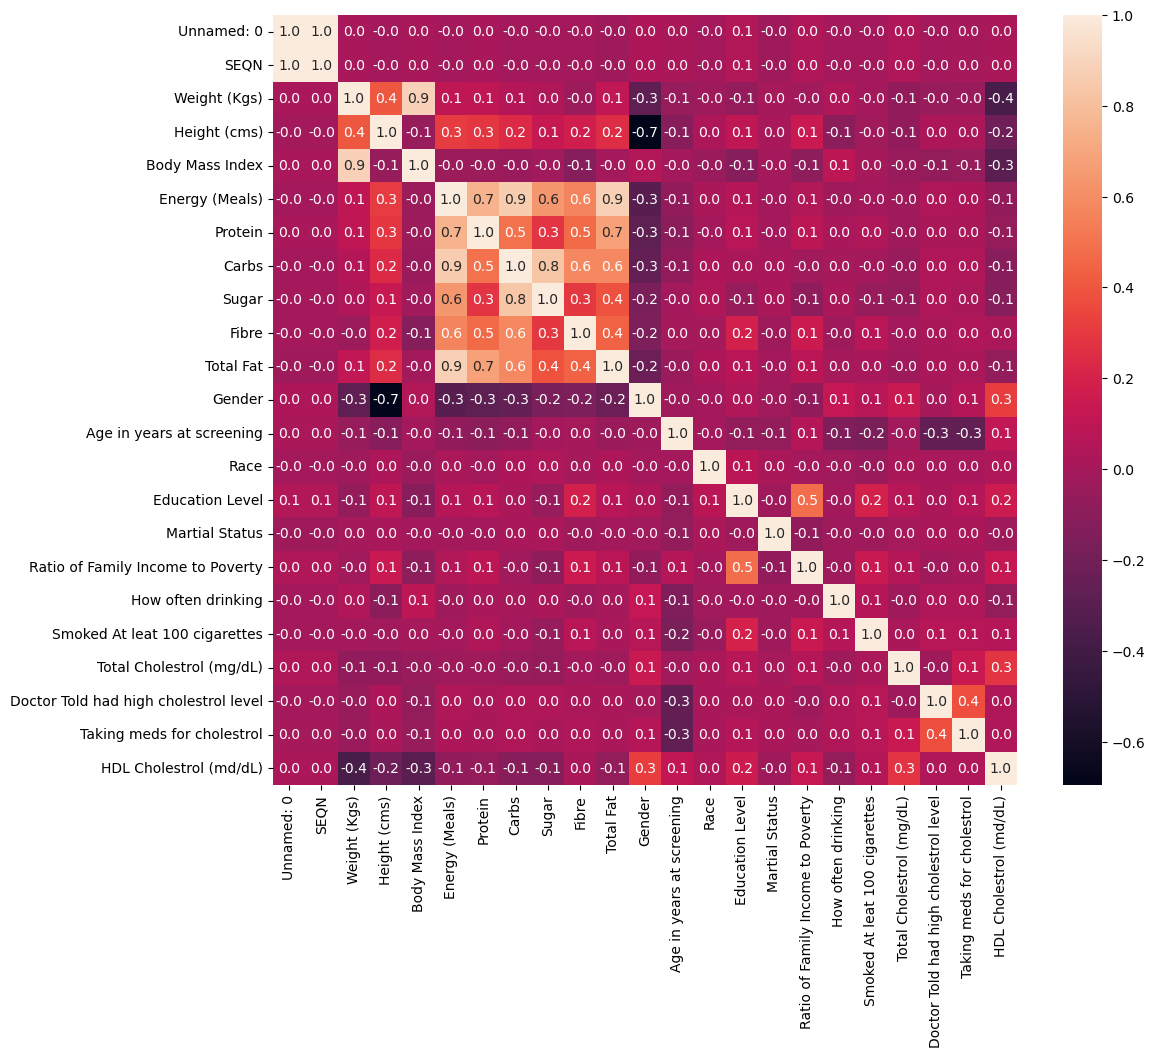

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt=".1f", ax=ax)

### Making the Graph 


In [ ]:
G = nx.DiGraph()
G.add_nodes_from(df.columns)
G.add_edges_from([('Anxiety', 'Smoking'),
                   ('Peer_Pressure', 'Smoking'),
                   ('Smoking', 'Yellow_Fingers'),
                   ('Smoking', 'Lung_cancer'),
                   ('Genetics', 'Lung_cancer'),
                   ('Genetics', 'Attention_Disorder'),
                   ('Lung_cancer', 'Fatigue'),
                   ('Lung_cancer', 'Coughing'),
                   ('Allergy', 'Coughing'),
                   ('Coughing', 'Fatigue'),
                   ('Attention_Disorder', 'Car_Accident'),
                   ('Fatigue', 'Car_Accident'),

                     ])
plt.figure(figsize=(12,12))

nx.draw_shell(G, with_labels=True, node_color = ['w', 'w', 'r', 'w', 'w', 'w', 'w', 'r', 'w', 'w', 'w', 'w'], arrowsize = 50, node_size = 10000, edgecolors='black', font_size=12)

In [ ]:
nx.write_gml(G, 'LUCAS.gml')

## Estimands

In [10]:
from dowhy.causal_identifier import backdoor
from dowhy import CausalModel

In [ ]:
# a utility function to parse the .gml file to string 
# From tutorial 3
def gml_to_string(file):
    gml_str = ''
    with open(file, 'r') as file:
        for line in file:
            gml_str += line.rstrip()
    return gml_str

In [ ]:
graph_str = gml_to_string('LUCAS.gml')

model=CausalModel(
    data = df,
    treatment='Anxiety',
    outcome='Car_Accident',
    graph=graph_str
)
model.view_model()

In [ ]:
identified_estimand = model.identify_effect()
print(identified_estimand)

In [ ]:
identifier = model.identifier
identifier.identify_backdoor(model._graph._graph, model._treatment, model._outcome, list(model._graph.get_all_nodes(include_unobserved=False)))

## Estimating Causal Effect

In [1]:
from sklearn.linear_model import LinearRegression

In [ ]:
causal_estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.linear_regression")
print(causal_estimate)
print("Causal Estimate is " + str(causal_estimate.value))

In [ ]:
# using the backdoor adjustment set and propensity score stratification
causal_estimate = model.estimate_effect(identified_estimand,
        method_name="iv.instrumental_variable")
print(causal_estimate)
print("Causal Estimate is " + str(causal_estimate.value))

## Causal Discovery 

### PC algorithm 

In [12]:
from pgmpy.estimators import PC


In [13]:
alpha = 0.05
pc = PC(df)
pc_graph = pc.estimate(ci_test='pillai', return_type='cpdag', significance_level=alpha)


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Unnamed: 0': 'N', 'SEQN': 'N', 'Weight (Kgs)': 'N', 'Height (cms)': 'N', 'Body Mass Index': 'N', 'Energy (Meals)': 'N', 'Protein': 'N', 'Carbs': 'N', 'Sugar': 'N', 'Fibre': 'N', 'Total Fat': 'N', 'Gender': 'N', 'Age in years at screening': 'N', 'Race': 'N', 'Education Level': 'N', 'Martial Status': 'N', 'Ratio of Family Income to Poverty': 'N', 'How often drinking': 'N', 'Smoked At leat 100 cigarettes': 'N', 'Total Cholestrol (mg/dL)': 'N', 'Doctor Told had high cholestrol level': 'N', 'Taking meds for cholestrol': 'N', 'HDL Cholestrol (md/dL)': 'N'}


  0%|          | 0/5 [00:00<?, ?it/s]

INFO:pgmpy:Reached maximum number of allowed conditional variables. Exiting


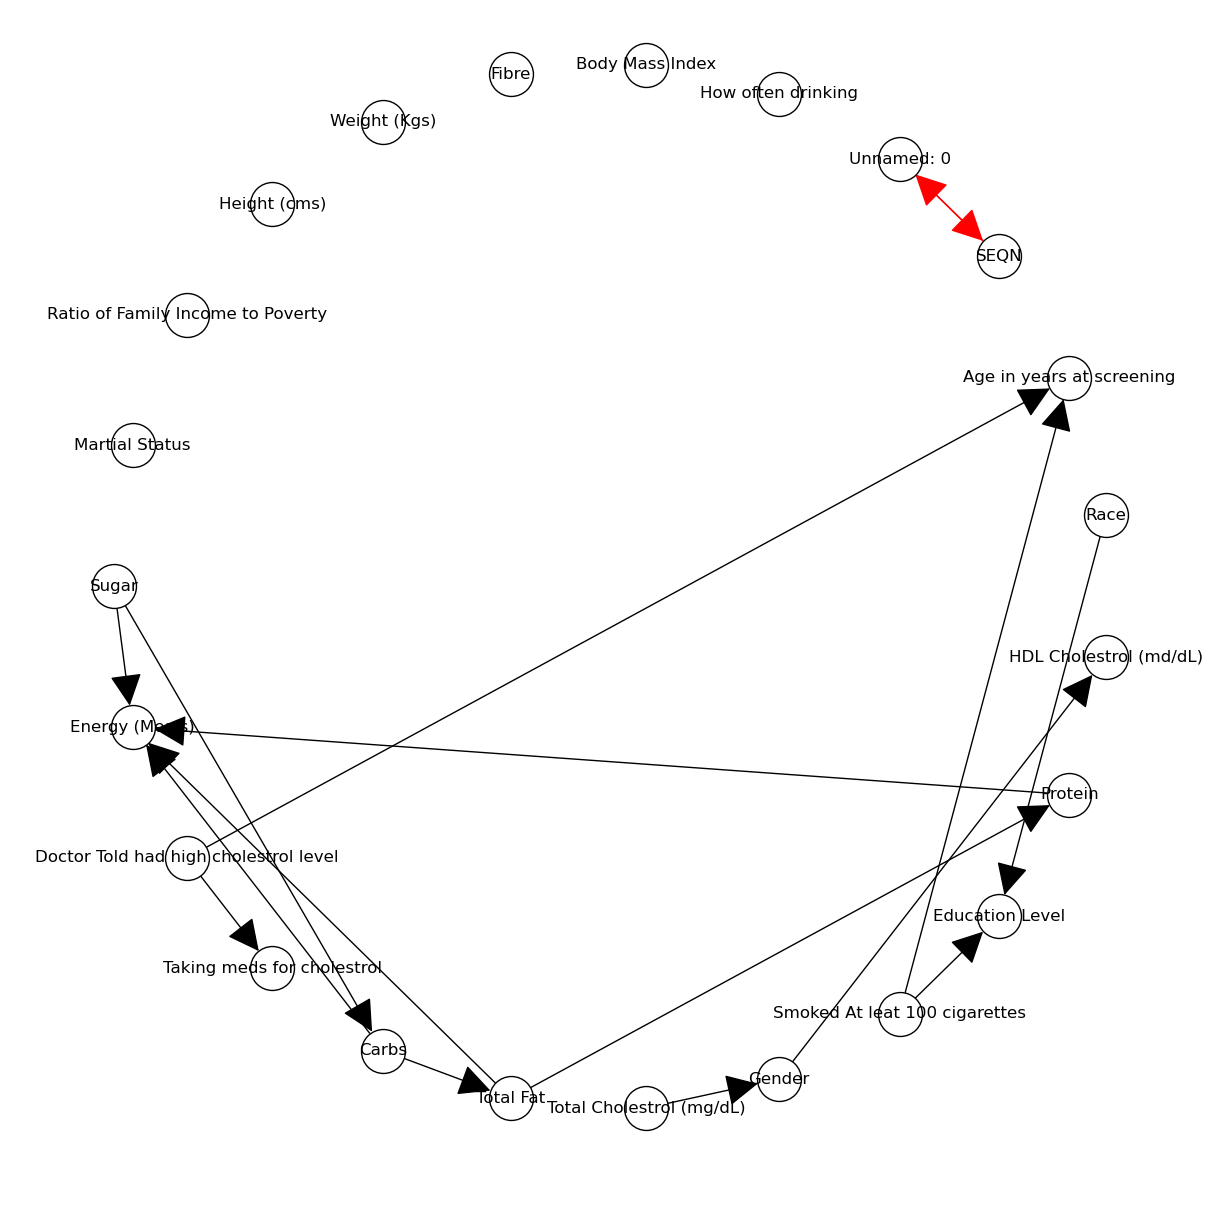

In [16]:
# Visualize the graph
plt.figure(figsize=(12,12))

colors = ['red'  if (y,x) in pc_graph.edges() else 'black' for (x,y) in pc_graph.edges()]
nx.draw_shell(pc_graph, with_labels=True, node_size=1000, font_size=12, arrowsize=50, node_color='w', edgecolors ='black', edge_color=colors)


INFO:dowhy.causal_model:Model to find the causal effect of treatment ['Anxiety'] on outcome ['Car_Accident']
INFO:dowhy.utils.plotting:Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


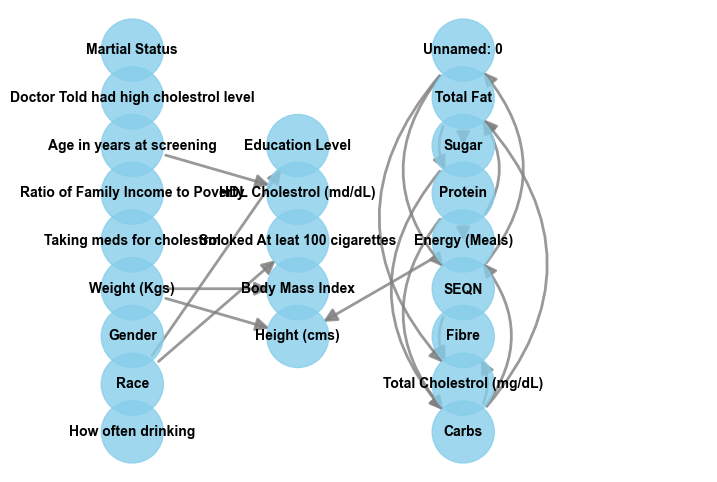

NetworkXError: The node Anxiety is not in the digraph.

In [14]:
gml = ''.join(nx.generate_gml(pc_graph))
model = CausalModel(
        data = df,
        treatment='Anxiety',
        outcome='Car_Accident',
        graph=gml)
model.view_model()

identified_estimand = model.identify_effect()
print(identified_estimand)

estimate = model.estimate_effect(identified_estimand,
        method_name="backdoor.linear_regression")
print("Causal Estimate is " + str(estimate.value))

INFO:dowhy.causal_model:Model to find the causal effect of treatment ['Protein'] on outcome ['HDL Cholestrol (md/dL)']
INFO:dowhy.utils.plotting:Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


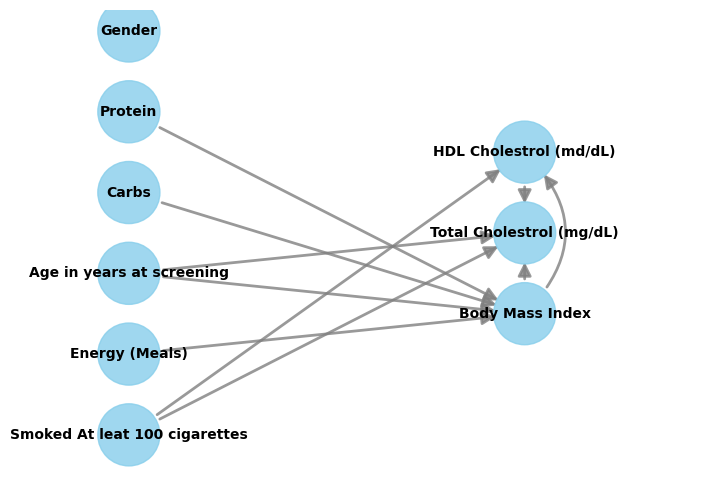

INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.
INFO:dowhy.causal_identifier.auto_identifier:Instrumental variables for treatment and outcome:[]
INFO:dowhy.causal_identifier.auto_identifier:Frontdoor variables for treatment and outcome:['Body Mass Index']
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.
INFO:dowhy.causal_identifier.auto_identifier:Causal effect can be identified.
INFO:dowhy.causal_model:linear_regression
INFO:dowhy.causal_estimator:INFO: Using Linear Regression Estimator
INFO:dowhy.causal_estimator:b: HDL Cholestrol (md/dL)~Protein+Protein*Smoked At leat 100 cigarettes+Protein*Carbs+Protein*Energy (Meals)+Protein*Age in years at screening
/Users/jeremypalmerio/opt/miniconda3/envs/CDS/lib/python3.11/site-packages/dowhy/causal_estimator.py:266: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obs

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                
──────────(E[HDL Cholestrol (md/dL)])
d[Protein]                           
Estimand assumption 1, Unconfoundedness: If U→{Protein} and U→HDL Cholestrol (md/dL) then P(HDL Cholestrol (md/dL)|Protein,,U) = P(HDL Cholestrol (md/dL)|Protein,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
Estimand expression:
 ⎡        d                                      d                        ⎤
E⎢──────────────────(HDL Cholestrol (md/dL))⋅──────────([Body Mass Index])⎥
 ⎣d[Body Mass Index]                         d[Protein]                   ⎦
Estimand assumption 1, Full-mediation: Body Mass Index intercepts (blocks) all directed paths from Protein to H,D,L, ,C,h,o,l,e,s,t,r,o,l, ,(,m,d,/,d,L,).
Estimand assumption 2, First-stage-unconfoundedness: If U→{Protein} and U→{Body Mass Index} then P(Body

/Users/jeremypalmerio/opt/miniconda3/envs/CDS/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/jeremypalmerio/opt/miniconda3/envs/CDS/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/jeremypalmerio/opt/miniconda3/envs/CDS/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions i

Causal Estimate is -0.029360017929448645


/Users/jeremypalmerio/opt/miniconda3/envs/CDS/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/jeremypalmerio/opt/miniconda3/envs/CDS/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  intercept_parameter = self.model.params[0]
/Users/jeremypalmerio/opt/miniconda3/envs/CDS/lib/python3.11/site-packages/dowhy/causal_estimators/regression_estimator.py:131: FutureWarning: Series.__getitem__ treating keys as positions i

In [21]:

import networkx as nx
from dowhy import CausalModel

pc_graph = nx.DiGraph()


pc_graph.add_nodes_from([
    'Body Mass Index',
    'Total Cholestrol (mg/dL)',
    'HDL Cholestrol (md/dL)',
    'Smoked At leat 100 cigarettes',  # Derived from 'Smoked At leat 100 cigarettes'
    'Age in years at screening',
    'Gender'
])

# BMI affects cholesterol levels
pc_graph.add_edge('Body Mass Index', 'Total Cholestrol (mg/dL)')
pc_graph.add_edge('Body Mass Index', 'HDL Cholestrol (md/dL)')

# Smoking affects cholesterol
pc_graph.add_edge('Smoked At leat 100 cigarettes', 'Total Cholestrol (mg/dL)')
pc_graph.add_edge('Smoked At leat 100 cigarettes', 'HDL Cholestrol (md/dL)')


# Age affects both BMI and cholesterol
pc_graph.add_edge('Age in years at screening', 'Body Mass Index')
pc_graph.add_edge('Age in years at screening', 'Total Cholestrol (mg/dL)')

# Diet factors affect BMI
pc_graph.add_edge('Energy (Meals)', 'Body Mass Index')
pc_graph.add_edge('Protein', 'Body Mass Index')
pc_graph.add_edge('Carbs', 'Body Mass Index')

pc_graph.add_edge('HDL Cholestrol (md/dL)',  'Total Cholestrol (mg/dL)')

gml = ''.join(nx.generate_gml(pc_graph))

model = CausalModel(
    data=df,
    treatment='Protein',  # Change treatment variable
    outcome='HDL Cholestrol (md/dL)',  # Change outcome variable
    graph=gml
)

# View and analyze the model
model.view_model()

identified_estimand = model.identify_effect()
print(identified_estimand)

estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)
print("Causal Estimate is " + str(estimate.value))

### GES 

In [24]:
df.shape

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Unnamed: 0': 'N', 'SEQN': 'N', 'Weight (Kgs)': 'N', 'Height (cms)': 'N', 'Body Mass Index': 'N', 'Energy (Meals)': 'N', 'Protein': 'N', 'Carbs': 'N', 'Sugar': 'N', 'Fibre': 'N', 'Total Fat': 'N', 'Gender': 'N', 'Age in years at screening': 'N', 'Race': 'N', 'Education Level': 'N', 'Martial Status': 'N', 'Ratio of Family Income to Poverty': 'N', 'How often drinking': 'N', 'Smoked At leat 100 cigarettes': 'N', 'Total Cholestrol (mg/dL)': 'N', 'Doctor Told had high cholestrol level': 'N', 'Taking meds for cholestrol': 'N', 'HDL Cholestrol (md/dL)': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'Unnamed: 0': 'N', 'SEQN': 'N', 'Weight (Kgs)': 'N', 'Height (cms)': 'N', 'Body Mass Index': 'N', 'Energy (Meals)': 'N', 'Protein': 'N', 'Carbs': 'N', 'Sugar': 'N', 'Fibre': 'N', 'Total Fat': 'N', 'Gender': 'N', 'Age in years at s

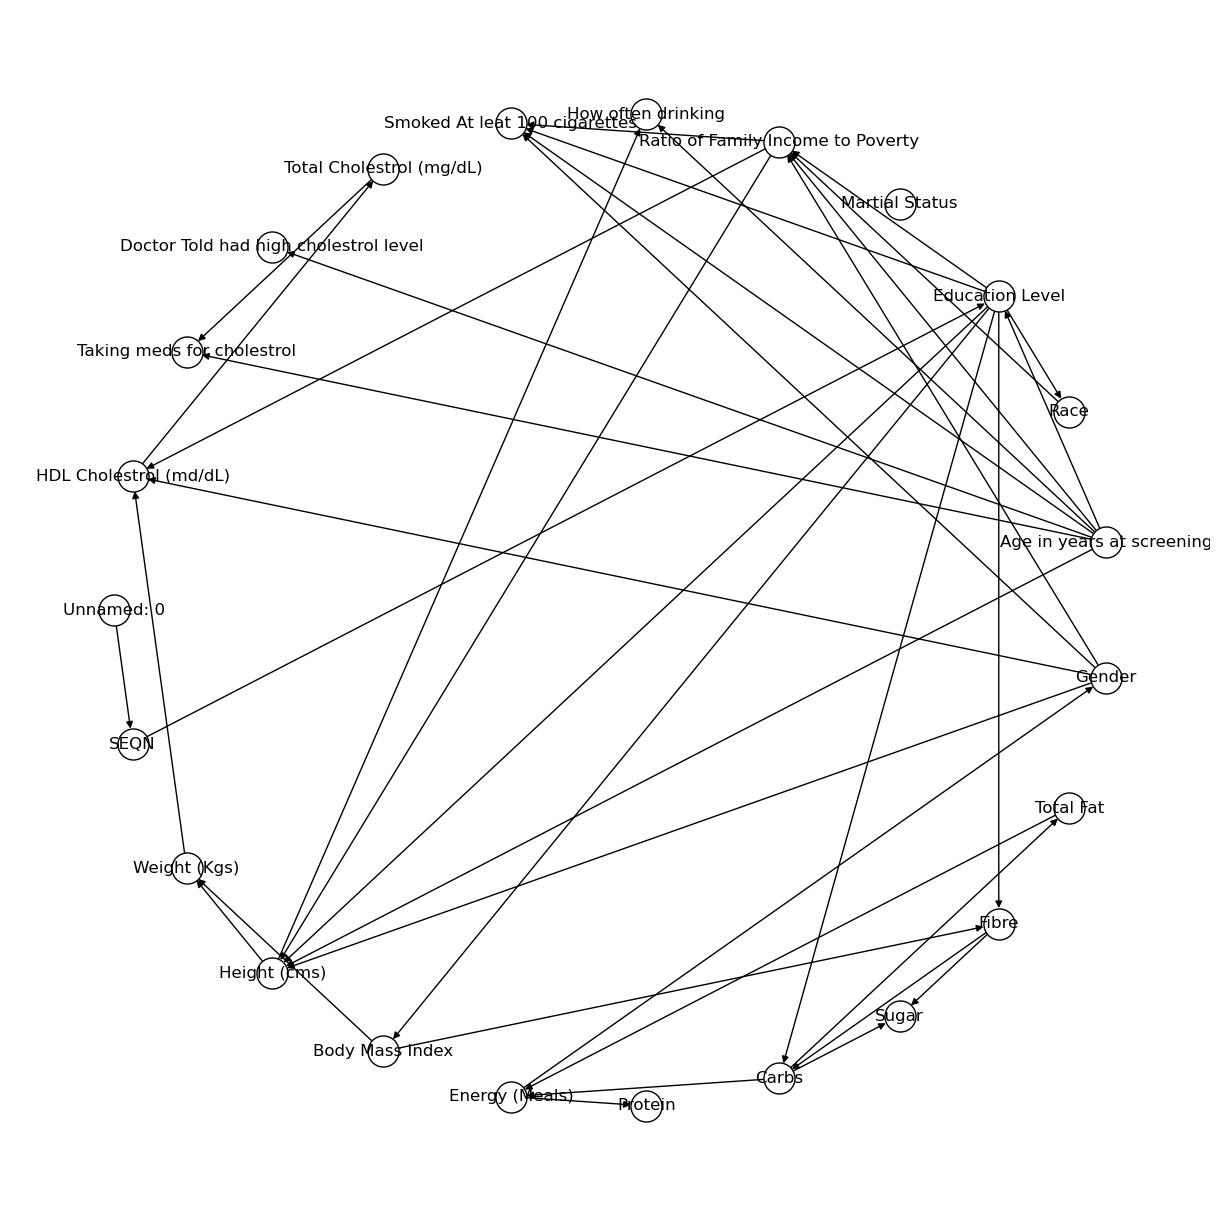

In [23]:
from pgmpy.estimators import GES as pgmpy_ges
from pgmpy.estimators import ExhaustiveSearch, HillClimbSearch, BDeu, BIC


ges_graph_pgmpy = pgmpy_ges(df).estimate(scoring_method='bic-cg')
colors = ['red'  if (y,x) in ges_graph_pgmpy.edges() else 'black' for (x,y) in ges_graph_pgmpy.edges()]

plt.figure(figsize=(12,12))
nx.draw_shell(ges_graph_pgmpy, with_labels=True, node_size=500, node_color='w', edgecolors ='black', edge_color=colors)